# 03 | YouBike 快照的 Pandas 分析

1.	用 Pandas 完成多時段資料的合併、清理、分組彙整與長寬表轉換。
2.	畫出中文標示正確、不會誤導讀者的圖表。
3.	說明每一個彙整決策（定義、分母、排除條件）怎麼改變結果，並用數字證明。

本週的重點不是「算出一個數字」，而是「知道這個數字是用什麼定義算出來的，換一個定義會差多少」。


## 1. 路徑設定

沿用 `00_Colab環境設定範本.ipynb` 的路徑設定：在 Colab 掛載 Google Drive，本機執行時則以 notebook 上一層作為專案資料夾。之後一律用 `RAW_DIR`、`PROCESSED_DIR`、`OUTPUT_DIR` 組合路徑。

In [80]:
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_DIR = Path("/content/drive/MyDrive/115-1_GISprog")
else:
    # 備援：本機執行時，notebook 位於 115-1_GISprog/notebooks/，上一層就是專案資料夾
    PROJECT_DIR = Path.cwd().parent

RAW_DIR = PROJECT_DIR / "data" / "raw"
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
OUTPUT_DIR = PROJECT_DIR / "outputs"
FONT_DIR = PROJECT_DIR / "fonts"

if not RAW_DIR.exists():
    raise FileNotFoundError(f"找不到 {RAW_DIR}，請確認 115-1_GISprog 資料夾位置是否正確")

print("執行環境：", "Google Colab" if IN_COLAB else "本機")
print("專案資料夾：", PROJECT_DIR)

執行環境： 本機
專案資料夾： c:\作業資料夾\112-1~115-1 程式設計相關課程\課堂習題或回家作業\python\python\GIS_Programming


## 2. 設定中文字型



In [81]:
import urllib.request

import matplotlib.pyplot as plt
from matplotlib import font_manager

FONT_URL = "https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_&export=download"
FONT_PATH = FONT_DIR / "TaipeiSansTCBeta-Regular.ttf"

if not FONT_PATH.exists():
    FONT_DIR.mkdir(parents=True, exist_ok=True)
    urllib.request.urlretrieve(FONT_URL, FONT_PATH)

font_manager.fontManager.addfont(str(FONT_PATH))
plt.rcParams["font.family"] = "Taipei Sans TC Beta"
plt.rcParams["axes.unicode_minus"] = False  # 讓負號正常顯示
print("已設定中文字型：", FONT_PATH.name)

已設定中文字型： TaipeiSansTCBeta-Regular.ttf


# 3. 合併成長表格
把至少 3 份快照讀進來，合併成一個長表格，並加上 snapshot_time 欄位。
* 讀進來後先印出 df.dtypes。用 pd.read_json() 讀檔的同學，檢查 act、sno 的型態（見課堂 notebook B1）。
* 印出每一份快照各有幾站。


In [82]:
import pandas as pd

# 列出 data/processed 底下所有的 YouBike 快照檔案
snapshot_files = sorted(PROCESSED_DIR.glob("youbike_*.json"))
for f in snapshot_files:
    print(f.name)

youbike_20260924_1120.json
youbike_20260924_1547.json
youbike_20260925_1230.json
youbike_20260925_1800.json
youbike_20260925_2330.json
youbike_20260930_1700.json
youbike_20261001_1358.json
youbike_20261007_1421.json


In [83]:
# 讀取每一份快照，從檔名取出時間戳記，加上 snapshot_time 欄位後合併成長表格
df_list = []
for f in snapshot_files:
    df_snapshot = pd.read_json(f)
    # 檔名格式為 youbike_YYYYMMDD_HHMM.json，用檔名當作這份快照的時間
    timestamp_str = f.stem.replace("youbike_", "")  # 例如 "20260924_1120"
    df_snapshot["snapshot_time"] = pd.to_datetime(timestamp_str, format="%Y%m%d_%H%M")
    df_list.append(df_snapshot)

df = pd.concat(df_list, ignore_index=True)
print("長表格總筆數：", len(df))

長表格總筆數： 14456


In [84]:
# 印出長表格每一欄的資料型態
print(df.dtypes)

sno                                int64
sna                               object
sarea                             object
mday                              object
ar                                object
sareaen                           object
snaen                             object
aren                              object
act                                int64
srcUpdateTime                     object
updateTime                        object
infoTime                          object
infoDate                          object
Quantity                           int64
available_rent_bikes               int64
latitude                         float64
longitude                        float64
available_return_bikes             int64
snapshot_time             datetime64[ns]
dtype: object


In [85]:
# 用 pd.read_json() 讀檔時，sno、act 可能被自動轉成數字型態，
# 這裡特別檢查這兩欄實際的型態與範例值
print("sno 型態：", df["sno"].dtype, "｜範例值：", df["sno"].iloc[0])
print("act 型態：", df["act"].dtype, "｜範例值：", df["act"].iloc[0])

sno 型態： int64 ｜範例值： 500101001
act 型態： int64 ｜範例值： 1


In [86]:
# 印出每一份快照各有幾個站點
print(df.groupby("snapshot_time").size())

snapshot_time
2026-09-24 11:20:00    1803
2026-09-24 15:47:00    1803
2026-09-25 12:30:00    1807
2026-09-25 18:00:00    1807
2026-09-25 23:30:00    1807
2026-09-30 17:00:00    1808
2026-10-01 13:58:00    1808
2026-10-07 14:21:00    1813
dtype: int64


## 4. 清理
型態轉換：`act` 轉成明確的 `True／False`，時間欄位用 `pd.to_datetime()` 轉換。


In [87]:
# 把 act（啟用狀態）轉成布林值："1" 表示站點啟用中，"0" 表示停用
# 先轉成字串再比較，不管原本被 pd.read_json() 讀成字串還是數字都能處理
df["act"] = df["act"].astype(str) == "1"
print("act 型態：", df["act"].dtype)
print(df["act"].value_counts())

act 型態： bool
act
True     14233
False      223
Name: count, dtype: int64


In [88]:
# 把資料裡的時間欄位都轉成 pandas 的 datetime 型態，方便之後做時間篩選與運算
time_columns = ["mday", "srcUpdateTime", "updateTime", "infoTime", "infoDate"]
for col in time_columns:
    df[col] = pd.to_datetime(df[col])

print(df[time_columns].dtypes)

mday             datetime64[ns]
srcUpdateTime    datetime64[ns]
updateTime       datetime64[ns]
infoTime         datetime64[ns]
infoDate         datetime64[ns]
dtype: object


In [89]:
# 印出每份快照的總站數、暫停營運站數與暫停站佔比，作為之後排除條件的依據
summary = df.groupby("snapshot_time")["act"].agg(["size", "sum"])
summary.columns = ["總站數", "營運中站數"]
summary["暫停站數"] = summary["總站數"] - summary["營運中站數"]
summary["暫停站佔比(%)"] = (summary["暫停站數"] / summary["總站數"] * 100).round(1)
print(summary)

                      總站數  營運中站數  暫停站數  暫停站佔比(%)
snapshot_time                                   
2026-09-24 11:20:00  1803   1773    30       1.7
2026-09-24 15:47:00  1803   1774    29       1.6
2026-09-25 12:30:00  1807   1780    27       1.5
2026-09-25 18:00:00  1807   1780    27       1.5
2026-09-25 23:30:00  1807   1780    27       1.5
2026-09-30 17:00:00  1808   1780    28       1.5
2026-10-01 13:58:00  1808   1780    28       1.5
2026-10-07 14:21:00  1813   1786    27       1.5


## 5. 分組彙整
以「行政區 × 時段」計算：
| 統計項目 | 說明 |
|:---:|:---:|
| 站數 | 分母用哪些站，由你決定並說明 |
| 可借車總數 | |	
| 空站比例 | 用你自己的定義 |
| 滿站比例 | 用你自己的定義 |

用 `pivot_table` 把空站比例轉成寬表（列是行政區、欄是時段）。
至少寫 1 個 `assert`，用手造的小資料測試你的空站（或滿站）比例函式，其中要包含一個暫停營運的站。


In [90]:
# 分母決策：預設只用「營運中」(act=True) 的站當分母。
# 理由：前面分析過，暫停營運的站留著殘留的借/還車數字，不是即時真實狀態，
# 算進分母或分子都會讓「空站比例」「滿站比例」失真，所以直接排除。
# include_inactive=True 則是故意不排除，用來跟預設版本比較差多少（見第 9 節）。

def calc_ratio(group, column, threshold=0, include_inactive=False):
    """計算一組站點裡，某欄位小於等於 threshold 的站數佔分母站數的比例（%）。
    預設（include_inactive=False）只用 act=True（營運中）的站當分母，
    暫停營運的站不計入分母也不計入分子。
    threshold=0（預設）就是原本「可借車數剛好 0 才算空站」的嚴格定義。
    """
    pool = group if include_inactive else group[group["act"]]
    if len(pool) == 0:
        return float("nan")
    return (pool[column] <= threshold).sum() / len(pool) * 100

In [91]:
# 空站定義：available_rent_bikes == 0（沒有車可借）
# 滿站定義：available_return_bikes == 0（沒有空位可還車）
def summarize_group(group):
    active = group[group["act"]]
    return pd.Series({
        "站數": len(active),
        "可借車總數": active["available_rent_bikes"].sum(),
        "空站比例(%)": round(calc_ratio(group, "available_rent_bikes"), 1),
        "滿站比例(%)": round(calc_ratio(group, "available_return_bikes"), 1),
    })

district_summary = df.groupby(["sarea", "snapshot_time"]).apply(summarize_group)
print(district_summary)

                              站數   可借車總數  空站比例(%)  滿站比例(%)
sarea snapshot_time                                       
中山區   2026-09-24 11:20:00  198.0  1701.0      6.6      1.5
      2026-09-24 15:47:00  199.0  1593.0      1.5      1.5
      2026-09-25 12:30:00  199.0  1906.0      4.0      1.5
      2026-09-25 18:00:00  199.0  1551.0      6.5      2.0
      2026-09-25 23:30:00  199.0  1932.0      5.5      3.0
...                          ...     ...      ...      ...
萬華區   2026-09-25 18:00:00   92.0   856.0      2.2      1.1
      2026-09-25 23:30:00   92.0  1054.0      1.1      1.1
      2026-09-30 17:00:00   92.0   967.0      2.2      1.1
      2026-10-01 13:58:00   92.0   889.0      3.3      0.0
      2026-10-07 14:21:00   93.0   669.0      6.5      0.0

[104 rows x 4 columns]


In [92]:
# 把空站比例轉成寬表：列是行政區、欄是時段
wide_empty_ratio = district_summary.reset_index().pivot_table(
    index="sarea", columns="snapshot_time", values="空站比例(%)"
)
print(wide_empty_ratio)

snapshot_time  2026-09-24 11:20:00  2026-09-24 15:47:00  2026-09-25 12:30:00  \
sarea                                                                          
中山區                            6.6                  1.5                  4.0   
中正區                            9.5                  9.5                  4.3   
信義區                           14.7                  5.4                  7.0   
內湖區                            4.5                  7.6                  4.0   
北投區                            6.1                  2.3                  0.0   
南港區                            4.1                  2.5                  2.5   
士林區                            4.6                  2.0                  4.6   
大同區                           10.7                  2.4                  2.4   
大安區                           12.3                  9.4                  8.9   
文山區                            0.8                  2.5                  0.8   
松山區                            7.5      

In [93]:
# 用手造的小資料測試 calc_ratio：3 站裡有 1 站暫停營運(act=False)
# 營運中只有 2 站，其中 1 站是空站(available_rent_bikes=0)，預期空站比例 = 1/2 = 50%
# 暫停營運那站雖然也是 0，但不該被算進分母或分子
test_df = pd.DataFrame({
    "act": [True, True, False],
    "available_rent_bikes": [0, 5, 0],
    "available_return_bikes": [3, 0, 0],
})

assert calc_ratio(test_df, "available_rent_bikes") == 50.0, "空站比例算錯了！"
assert calc_ratio(test_df, "available_return_bikes") == 50.0, "滿站比例算錯了！"
print("✅ calc_ratio 測試通過：暫停營運的站有被正確排除")

✅ calc_ratio 測試通過：暫停營運的站有被正確排除


## 6.  畫圖
畫一張圖比較各區在不同時段的空站比例：
* 中文標題、軸標籤、圖例都要正確顯示。
* 標題或副標題要寫出你用的空站定義與資料時間。
* 如果畫多張子圖互相比較，要用相同的座標範圍。


In [94]:
# 13 個行政區太多，如果每區畫一條線、配一個顏色會很難分辨（類別色超過幾種就會混淆）。
# 空站比例是「程度高低」的資料，比較適合用熱力圖：同一色系，顏色越深代表空站比例越高。
from matplotlib.colors import LinearSegmentedColormap

blue_steps = [
    "#cde2fb", "#b7d3f6", "#9ec5f4", "#86b6ef", "#6da7ec", "#5598e7",
    "#3987e5", "#2a78d6", "#256abf", "#1c5cab", "#184f95", "#104281", "#0d366b",
]
seq_blue = LinearSegmentedColormap.from_list("seq_blue", blue_steps)
seq_blue.set_bad(color="#e1e0d9")  # 沒有資料的格子用淺灰色標示

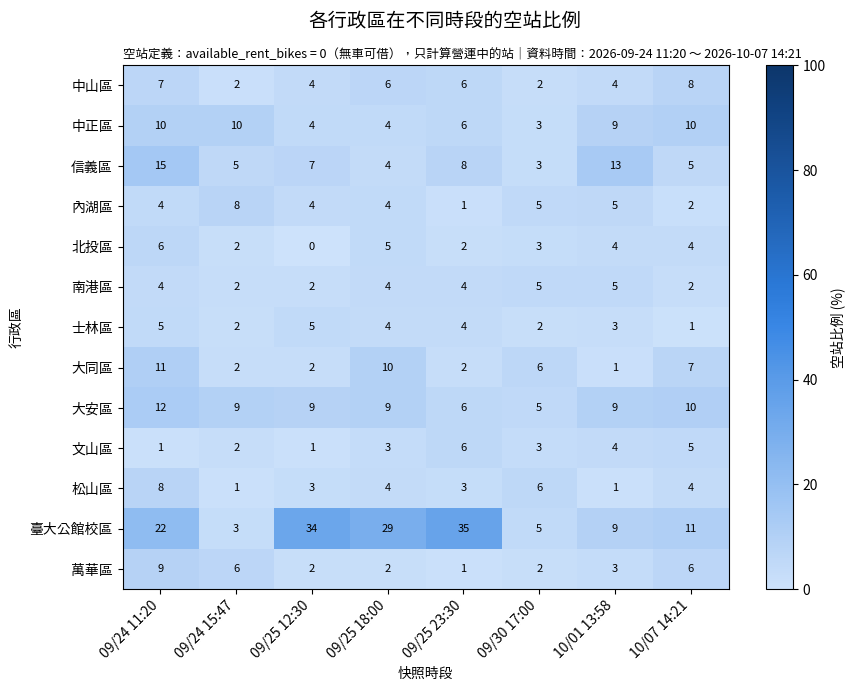

In [95]:
import numpy as np

# 畫熱力圖：列是行政區、欄是時段，顏色深淺代表空站比例，每一格再標出實際數字
fig, ax = plt.subplots(figsize=(9, 7))

data = wide_empty_ratio.values
im = ax.imshow(data, cmap=seq_blue, vmin=0, vmax=100, aspect="auto")

ax.set_xticks(range(len(wide_empty_ratio.columns)))
ax.set_xticklabels(
    [t.strftime("%m/%d %H:%M") for t in wide_empty_ratio.columns], rotation=45, ha="right"
)
ax.set_yticks(range(len(wide_empty_ratio.index)))
ax.set_yticklabels(wide_empty_ratio.index)

# 每一格標出數值，顏色太深時用白字，避免看不清楚
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        value = data[i, j]
        if np.isnan(value):
            continue
        text_color = "white" if value > 50 else "black"
        ax.text(j, i, f"{value:.0f}", ha="center", va="center", color=text_color, fontsize=8)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("空站比例 (%)")

ax.set_xlabel("快照時段")
ax.set_ylabel("行政區")

time_start = wide_empty_ratio.columns.min().strftime("%Y-%m-%d %H:%M")
time_end = wide_empty_ratio.columns.max().strftime("%Y-%m-%d %H:%M")
fig.suptitle("各行政區在不同時段的空站比例", fontsize=14)
ax.set_title(
    f"空站定義：available_rent_bikes = 0（無車可借），只計算營運中的站｜資料時間：{time_start} ～ {time_end}",
    fontsize=9, loc="left",
)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "03_空站比例熱力圖.png", dpi=150)
plt.show()

# 7. 輸出
把清理後的長表格存成 CSV，放在 `data/processed/`，用 `encoding="utf-8-sig"`。

In [96]:
# 把清理後的長表格輸出成 CSV，之後開 Excel 或在其他 notebook 讀取都能直接用
output_path = PROCESSED_DIR / "03_youbike_snapshots_clean.csv"
df.to_csv(output_path, index=False, encoding="utf-8-sig")
print("已輸出至：", output_path)

已輸出至： c:\作業資料夾\112-1~115-1 程式設計相關課程\課堂習題或回家作業\python\python\GIS_Programming\data\processed\03_youbike_snapshots_clean.csv


## 8. 比較兩種空站定義
用兩種定義各算一次空站比例，比較「結論」（哪個行政區空站比例最高）有沒有改變：
* 定義一（嚴格）：`available_rent_bikes == 0`，前面小節用的定義。
* 定義二（寬鬆）：`available_rent_bikes <= 2`，車太少也視為空站。

In [97]:
# 定義一（嚴格）沿用第 5 節算好的 wide_empty_ratio（available_rent_bikes == 0）
# 定義二（寬鬆）：available_rent_bikes <= 2，重新算一次空站比例
empty_ratio_def2 = df.groupby(["sarea", "snapshot_time"]).apply(
    lambda g: calc_ratio(g, "available_rent_bikes", threshold=2)
)
empty_ratio_def2.name = "空站比例(%)"

wide_empty_ratio_def2 = empty_ratio_def2.reset_index().pivot(
    index="sarea", columns="snapshot_time", values="空站比例(%)"
).round(1)

print("定義二（可借車數 <= 2）的空站比例寬表：")
print(wide_empty_ratio_def2)

定義二（可借車數 <= 2）的空站比例寬表：
snapshot_time  2026-09-24 11:20:00  2026-09-24 15:47:00  2026-09-25 12:30:00  \
sarea                                                                          
中山區                           17.2                 23.1                 17.1   
中正區                           29.2                 26.3                 15.2   
信義區                           35.7                 23.3                 27.9   
內湖區                           25.0                 22.8                 20.8   
北投區                           23.7                 16.8                 11.5   
南港區                           24.6                 15.6                 16.4   
士林區                           19.2                 14.6                 15.8   
大同區                           26.2                 25.0                 13.1   
大安區                           42.0                 30.2                 24.4   
文山區                           18.2                 14.9                 10.7   
松山區              

In [98]:
# 兩種定義逐格相減，看數字差多少（百分點）
# 用 nanmean／nanmax，避免某行政區在某時段剛好 0 站營運中造成的 NaN 影響計算
diff = (wide_empty_ratio_def2 - wide_empty_ratio).round(1)
print("定義二（<=2）減定義一（=0）的差異（百分點）：")
print(diff)
print()
print(f"差異平均：{np.nanmean(diff.values):.1f} 個百分點，最大：{np.nanmax(diff.values):.1f} 個百分點")

定義二（<=2）減定義一（=0）的差異（百分點）：
snapshot_time  2026-09-24 11:20:00  2026-09-24 15:47:00  2026-09-25 12:30:00  \
sarea                                                                          
中山區                           10.6                 21.6                 13.1   
中正區                           19.7                 16.8                 10.9   
信義區                           21.0                 17.9                 20.9   
內湖區                           20.5                 15.2                 16.8   
北投區                           17.6                 14.5                 11.5   
南港區                           20.5                 13.1                 13.9   
士林區                           14.6                 12.6                 11.2   
大同區                           15.5                 22.6                 10.7   
大安區                           29.7                 20.8                 15.5   
文山區                           17.4                 12.4                  9.9   
松山區           

In [99]:
# 真正要看的「結論」：每個時段，空站比例最高的是哪個行政區，兩種定義選出的是不是同一個
highest_def1 = wide_empty_ratio.idxmax()
highest_def2 = wide_empty_ratio_def2.idxmax()

print("定義一（可借=0）各時段空站比例最高的行政區：")
print(highest_def1)
print()
print("定義二（可借<=2）各時段空站比例最高的行政區：")
print(highest_def2)
print()

same = highest_def1 == highest_def2
print("兩種定義選出的「最高」行政區是否一致：")
print(same)
print()

if same.all():
    print("結論：兩種定義下，每個時段「空站比例最高」的行政區都一樣，結論沒有改變。")
else:
    changed = same[~same].index.tolist()
    print(f"結論：有 {len(changed)} 個時段選出不同的行政區（{changed}），換一個定義會改變結論。")

定義一（可借=0）各時段空站比例最高的行政區：
snapshot_time
2026-09-24 11:20:00    臺大公館校區
2026-09-24 15:47:00       中正區
2026-09-25 12:30:00    臺大公館校區
2026-09-25 18:00:00    臺大公館校區
2026-09-25 23:30:00    臺大公館校區
2026-09-30 17:00:00       大同區
2026-10-01 13:58:00       信義區
2026-10-07 14:21:00    臺大公館校區
dtype: object

定義二（可借<=2）各時段空站比例最高的行政區：
snapshot_time
2026-09-24 11:20:00       大安區
2026-09-24 15:47:00       大安區
2026-09-25 12:30:00    臺大公館校區
2026-09-25 18:00:00    臺大公館校區
2026-09-25 23:30:00    臺大公館校區
2026-09-30 17:00:00       內湖區
2026-10-01 13:58:00       內湖區
2026-10-07 14:21:00       中正區
dtype: object

兩種定義選出的「最高」行政區是否一致：
snapshot_time
2026-09-24 11:20:00    False
2026-09-24 15:47:00    False
2026-09-25 12:30:00     True
2026-09-25 18:00:00     True
2026-09-25 23:30:00     True
2026-09-30 17:00:00    False
2026-10-01 13:58:00    False
2026-10-07 14:21:00    False
dtype: bool

結論：有 5 個時段選出不同的行政區（[Timestamp('2026-09-24 11:20:00'), Timestamp('2026-09-24 15:47:00'), Timestamp('2026-09-30 17:00:00'), Timestamp('2

## 9. 包含 vs 不包含暫停營運站
比較分母要不要排除暫停營運站，結果差多少、哪幾個行政區差最多，並說明原因。

In [100]:
# 含暫停營運站版本：分母、分子都用全部站（include_inactive=True），不排除暫停站
empty_ratio_incl = df.groupby(["sarea", "snapshot_time"]).apply(
    lambda g: calc_ratio(g, "available_rent_bikes", threshold=0, include_inactive=True)
)
empty_ratio_incl.name = "空站比例(%)"

wide_empty_ratio_incl = empty_ratio_incl.reset_index().pivot(
    index="sarea", columns="snapshot_time", values="空站比例(%)"
).round(1)

print("含暫停營運站的空站比例寬表：")
print(wide_empty_ratio_incl)

含暫停營運站的空站比例寬表：
snapshot_time  2026-09-24 11:20:00  2026-09-24 15:47:00  2026-09-25 12:30:00  \
sarea                                                                          
中山區                            9.8                  4.4                  6.8   
中正區                           10.1                 10.1                  4.3   
信義區                           14.7                  5.4                  7.0   
內湖區                            4.9                  8.0                  4.4   
北投區                            7.5                  3.8                  1.5   
南港區                            4.1                  2.5                  2.5   
士林區                            7.1                  4.5                  7.1   
大同區                           10.7                  2.4                  2.4   
大安區                           13.9                 11.1                 10.6   
文山區                            3.2                  4.0                  1.6   
松山區                      

In [101]:
# 逐格相減，再算每個行政區橫跨所有時段的平均差異，由大到小排序
diff_inactive = (wide_empty_ratio_incl - wide_empty_ratio).round(1)
print("含暫停站 - 不含暫停站 的差異（百分點）：")
print(diff_inactive)
print()

avg_diff_by_area = diff_inactive.mean(axis=1).sort_values(ascending=False)
print("各行政區平均差異（由大到小）：")
print(avg_diff_by_area)

含暫停站 - 不含暫停站 的差異（百分點）：
snapshot_time  2026-09-24 11:20:00  2026-09-24 15:47:00  2026-09-25 12:30:00  \
sarea                                                                          
中山區                            3.2                  2.9                  2.8   
中正區                            0.6                  0.6                  0.0   
信義區                            0.0                  0.0                  0.0   
內湖區                            0.4                  0.4                  0.4   
北投區                            1.4                  1.5                  1.5   
南港區                            0.0                  0.0                  0.0   
士林區                            2.5                  2.5                  2.5   
大同區                            0.0                  0.0                  0.0   
大安區                            1.6                  1.7                  1.7   
文山區                            2.4                  1.5                  0.8   
松山區              

In [102]:
# 為什麼差異大小不同：看每個行政區暫停營運站的次數與佔比，跟上面的平均差異放在一起比對
suspend_stats = df.groupby("sarea")["act"].agg(["size", "sum"])
suspend_stats.columns = ["總站次數", "營運中站次數"]
suspend_stats["暫停站次數"] = suspend_stats["總站次數"] - suspend_stats["營運中站次數"]
suspend_stats["暫停占比(%)"] = (suspend_stats["暫停站次數"] / suspend_stats["總站次數"] * 100).round(1)
suspend_stats["平均差異(pp)"] = avg_diff_by_area

print(suspend_stats.sort_values("平均差異(pp)", ascending=False))

top_area = suspend_stats["平均差異(pp)"].idxmax()
print(f"\n結論：{top_area} 的空站比例受「要不要排除暫停站」影響最大，"
      f"因為它的暫停站佔比（{suspend_stats.loc[top_area, '暫停占比(%)']}%）是所有行政區裡最高的——"
      "暫停站幾乎都回報可借車數 0，分母裡混進去的暫停站比例越高，空站比例就被墊得越高。"
      "暫停站佔比是 0 的行政區（例如完全沒有暫停站紀錄的區），含不含暫停站則完全沒有差別。")

        總站次數  營運中站次數  暫停站次數  暫停占比(%)  平均差異(pp)
sarea                                         
萬華區      784     737     47      6.0    4.7000
中山區     1642    1593     49      3.0    2.8500
士林區     1246    1213     33      2.6    2.5750
大安區     1735    1703     32      1.8    1.7000
北投區     1065    1049     16      1.5    1.4500
文山區      992     974     18      1.8    1.0375
松山區      865     857      8      0.9    0.9125
內湖區     1820    1804     16      0.9    0.4125
信義區     1032    1030      2      0.2    0.1875
中正區     1104    1102      2      0.2    0.1500
南港區      979     979      0      0.0    0.0000
大同區      672     672      0      0.0    0.0000
臺大公館校區   520     520      0      0.0    0.0000

結論：萬華區 的空站比例受「要不要排除暫停站」影響最大，因為它的暫停站佔比（6.0%）是所有行政區裡最高的——暫停站幾乎都回報可借車數 0，分母裡混進去的暫停站比例越高，空站比例就被墊得越高。暫停站佔比是 0 的行政區（例如完全沒有暫停站紀錄的區），含不含暫停站則完全沒有差別。
